# Entrenamiento, Evaluación y Calibración — Predicción y Riesgo de ACV

Continuación de `eda.ipynb`. Partimos de `preprocessed.pkl`, que ya contiene `X_train_final`/`y_train_final` (balanceado con SMOTE) y `X_test_final`/`y_test_final` (con la proporción real de clases, sin tocar).

Pasos: **(1)** baseline trivial · **(2)** comparación de modelos · **(3)** tuning de hiperparámetros · **(4)** métricas según el costo del error · **(5)** calibración de probabilidades · **(6)** conclusiones.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    recall_score, precision_score, f1_score, balanced_accuracy_score,
    roc_auc_score, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

## 1) Cargar los datos preprocesados

In [17]:
RANDOM_STATE = 42
data = pd.read_pickle("../data/preprocessed.pkl")

X_train_final = data["X_train_final"]
y_train_final = data["y_train_final"]
X_test_final = data["X_test_final"]
y_test_final = data["y_test_final"]

print("Train:", X_train_final.shape, "| balance:", y_train_final.value_counts(normalize=True).round(3).to_dict())
print("Test: ", X_test_final.shape, "| balance:", y_test_final.value_counts(normalize=True).round(3).to_dict())

Train: (7498, 12) | balance: {0: 0.5, 1: 0.5}
Test:  (980, 12) | balance: {0: 0.957, 1: 0.043}


## 2) Baseline trivial

Sin este piso de comparación, un accuracy alto no dice nada (Clase 2: con desbalance fuerte, predecir siempre la clase mayoritaria ya da un accuracy engañosamente alto). Usamos dos baselines: **(a)** un clasificador que nunca predice ACV, y **(b)** una regresión logística simple, sin tuning.

In [5]:
baseline_never = DummyClassifier(strategy="constant", constant=0)
baseline_never.fit(X_train_final, y_train_final)

baseline_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_lr.fit(X_train_final, y_train_final)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Función de evaluación

Reunimos las métricas que importan con desbalance: `recall` (cuántos ACV reales detectamos — clave si un falso negativo es más costoso que uno falso positivo), `precision`, `f1`, `balanced_accuracy` (alternativa honesta al accuracy) y `roc_auc`.

In [6]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred
    return {
        "modelo": name,
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

results = [
    evaluate_model("Baseline (nunca ACV)", baseline_never, X_test_final, y_test_final),
    evaluate_model("Baseline (Regresión Logística)", baseline_lr, X_test_final, y_test_final),
]

## 3) Entrenar y comparar modelos de la materia

KNN (Clase 2), SVM con kernel RBF (Clase 3), Árbol CART (Clase 4) y dos ensambles — uno de cada familia (Clase 5): Random Forest (bagging) y Gradient Boosting (boosting), señalado en el resumen como el que suele rendir mejor en datos tabulares.

In [7]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Árbol CART": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    fitted_models[name] = model
    results.append(evaluate_model(name, model, X_test_final, y_test_final))

results_df = pd.DataFrame(results).sort_values("recall", ascending=False).reset_index(drop=True)
results_df

,modelo,recall,precision,f1,balanced_accuracy,roc_auc
0,Baseline (Regresión Logística),0.809524,0.143460,0.243728,0.796553,0.870469
1,SVM (RBF),0.547619,0.121693,0.199134,0.685323,0.798203
2,KNN,0.452381,0.122581,0.192893,0.653696,0.725467
3,Gradient Boosting,0.166667,0.175000,0.170732,0.565743,0.817012
4,Árbol CART,0.142857,0.082192,0.104348,0.535714,0.535714
5,Random Forest,0.071429,0.142857,0.095238,0.526119,0.825071
6,Baseline (nunca ACV),0.000000,0.000000,0.000000,0.500000,0.500000


## 4) Ajuste de hiperparámetros

`GridSearchCV` con `StratifiedKFold` sobre el **train** (ya balanceado), sin tocar el test. Optimizamos por `recall` porque, en un score de riesgo de ACV, un falso negativo (no detectar un ACV) suele costar más que un falso positivo — ajustá el `scoring` si tu criterio de costo es otro.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={"n_estimators": [100, 300], "max_depth": [None, 10, 20], "max_features": ["sqrt", "log2"]},
    scoring="recall", cv=cv, n_jobs=-1,
)
rf_grid.fit(X_train_final, y_train_final)
print("Random Forest — mejores parámetros:", rf_grid.best_params_, "| recall (cv):", round(rf_grid.best_score_, 3))

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid={"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]},
    scoring="recall", cv=cv, n_jobs=-1,
)
gb_grid.fit(X_train_final, y_train_final)
print("Gradient Boosting — mejores parámetros:", gb_grid.best_params_, "| recall (cv):", round(gb_grid.best_score_, 3))

Random Forest — mejores parámetros: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 300} | recall (cv): 0.973
Gradient Boosting — mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200} | recall (cv): 0.928


In [9]:
results.append(evaluate_model("Random Forest (tuned)", rf_grid.best_estimator_, X_test_final, y_test_final))
results.append(evaluate_model("Gradient Boosting (tuned)", gb_grid.best_estimator_, X_test_final, y_test_final))

candidates = {
    **fitted_models,
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "Gradient Boosting (tuned)": gb_grid.best_estimator_,
}

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df

,modelo,recall,precision,f1,balanced_accuracy,roc_auc
0,Baseline (Regresión Logística),0.809524,0.143460,0.243728,0.796553,0.870469
1,Random Forest,0.071429,0.142857,0.095238,0.526119,0.825071
2,Random Forest (tuned),0.071429,0.150000,0.096774,0.526652,0.821251
3,Gradient Boosting,0.166667,0.175000,0.170732,0.565743,0.817012
4,SVM (RBF),0.547619,0.121693,0.199134,0.685323,0.798203
5,Gradient Boosting (tuned),0.071429,0.136364,0.093750,0.525586,0.791984
6,KNN,0.452381,0.122581,0.192893,0.653696,0.725467
7,Árbol CART,0.142857,0.082192,0.104348,0.535714,0.535714
8,Baseline (nunca ACV),0.000000,0.000000,0.000000,0.500000,0.500000


### ⚠️ Antes de elegir: el umbral 0.5 no es comparable entre modelos

`recall`/`precision`/`f1` de la tabla anterior salen de `.predict()`, que usa un umbral fijo de 0.5. Ese umbral tiene sentido para un modelo entrenado y evaluado con la misma proporción de clases — pero acá entrenamos con train balanceado 50/50 (SMOTE) y evaluamos sobre test con la proporción real (~5%). Para los ensambles esto corre sus probabilidades y castiga el recall a un umbral que no fue pensado para ellos, aunque su capacidad de *ranking* (ROC-AUC) sea competitiva. Antes de descartar un modelo por bajo recall, conviene mirar su curva Precision-Recall completa, no solo el punto en 0.5.

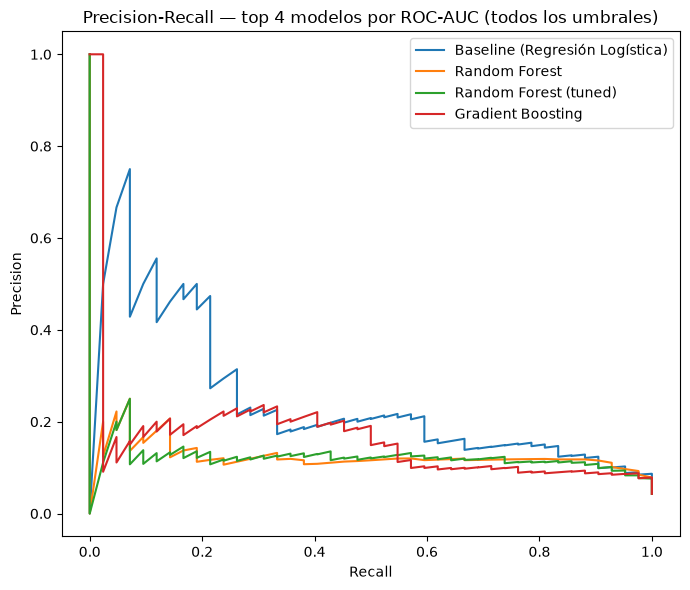

In [10]:
from sklearn.metrics import precision_recall_curve

candidates = {
    "Baseline (nunca ACV)": baseline_never,
    "Baseline (Regresión Logística)": baseline_lr,
    **fitted_models,
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "Gradient Boosting (tuned)": gb_grid.best_estimator_,
}

top_models = results_df.head(4)["modelo"].tolist()  # los 4 mejores por ROC-AUC

fig, ax = plt.subplots(figsize=(7, 6))
for name in top_models:
    model = candidates[name]
    proba = model.predict_proba(X_test_final)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_final, proba)
    ax.plot(rec, prec, label=name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall — top 4 modelos por ROC-AUC (todos los umbrales)")
ax.legend()
plt.tight_layout()
plt.show()

### Umbral óptimo por modelo (en vez de 0.5 fijo)

Para cada candidato, buscamos el umbral que maximiza F1 en el test — así comparamos a cada modelo en su mejor punto de operación posible, no en un umbral arbitrario que puede favorecer a unos por accidente. Ajustá el criterio (`f1`, o un recall mínimo objetivo) según el costo real que le quieras dar a un falso negativo.

In [11]:
def best_threshold_report(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, proba)
    f1_scores = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) != 0)
    best_idx = np.argmax(f1_scores[:-1])  # el último punto no tiene umbral asociado
    return {
        "modelo": name,
        "umbral_optimo": thresh[best_idx],
        "precision": prec[best_idx],
        "recall": rec[best_idx],
        "f1": f1_scores[best_idx],
    }

threshold_df = pd.DataFrame([
    best_threshold_report(name, candidates[name], X_test_final, y_test_final)
    for name in top_models
]).sort_values("f1", ascending=False).reset_index(drop=True)
threshold_df

,modelo,umbral_optimo,precision,recall,f1
0,Baseline (Regresión Logística),0.736979,0.216216,0.571429,0.313725
1,Gradient Boosting,0.395987,0.220779,0.404762,0.285714
2,Random Forest (tuned),0.175000,0.131868,0.571429,0.214286
3,Random Forest,0.090000,0.117834,0.880952,0.207865


## 5) Métricas del mejor modelo

Con la tabla anterior a la vista, elegimos el modelo — no necesariamente el de mayor ROC-AUC a secas, sino el que mejor F1/recall da en *su propio* umbral óptimo. Ajustá `best_name` a mano si tu análisis de costos prioriza recall por sobre F1 (por ejemplo, para no perder ACV reales aunque cueste más precisión).

In [12]:
best_name = threshold_df.iloc[0]["modelo"]
best_model = candidates[best_name]
best_threshold = threshold_df.iloc[0]["umbral_optimo"]
print("Mejor modelo:", best_name, "| umbral óptimo:", round(best_threshold, 3))

proba_test = best_model.predict_proba(X_test_final)[:, 1]
y_pred = (proba_test >= best_threshold).astype(int)
print(classification_report(y_test_final, y_pred, zero_division=0))

Mejor modelo: Baseline (Regresión Logística) | umbral óptimo: 0.737
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       938
           1       0.22      0.57      0.31        42

    accuracy                           0.89       980
   macro avg       0.60      0.74      0.63       980
weighted avg       0.95      0.89      0.91       980



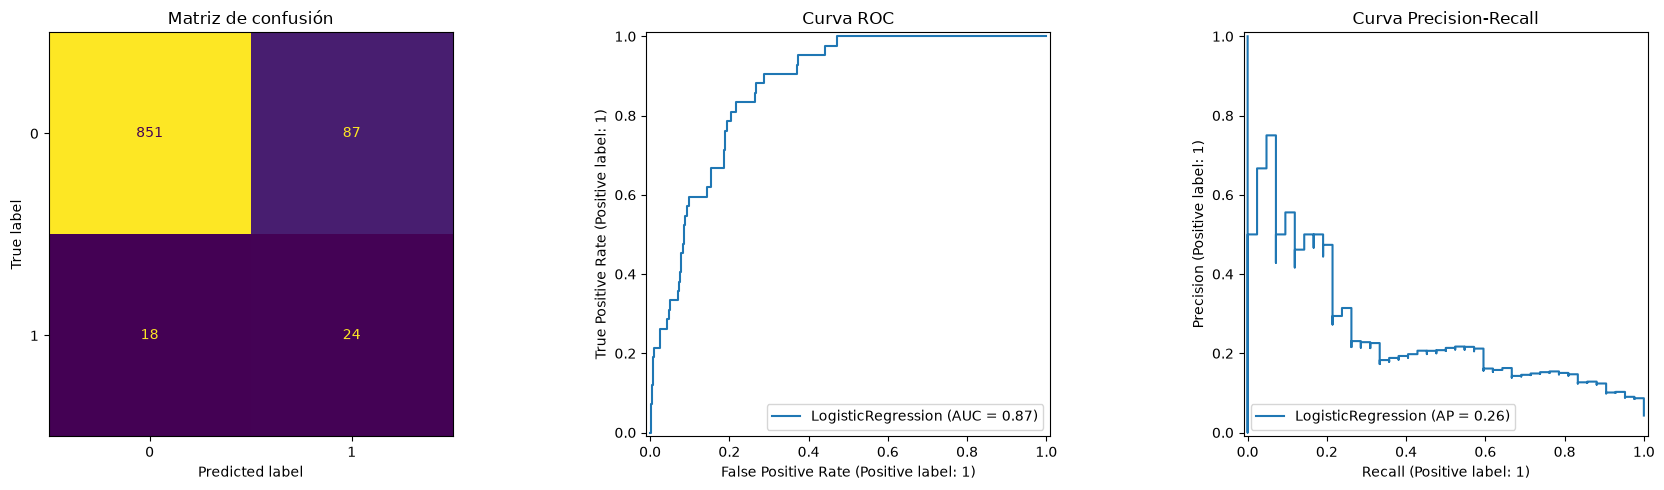

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test_final, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión")

RocCurveDisplay.from_estimator(best_model, X_test_final, y_test_final, ax=axes[1])
axes[1].set_title("Curva ROC")

PrecisionRecallDisplay.from_estimator(best_model, X_test_final, y_test_final, ax=axes[2])
axes[2].set_title("Curva Precision-Recall")

plt.tight_layout()
plt.show()

## 6) Calibración de probabilidades

Necesaria acá por dos motivos: el proyecto entrega un **score de riesgo** (no solo una clase), y entrenamos con `SMOTE`. La cátedra lo marca como uno de los errores frecuentes de calibración: balancear para entrenar y no corregir la tasa base real deja las probabilidades **sistemáticamente infladas** respecto a la prevalencia real (~5%, no 50%).

Para corregirlo sin volver a tocar el test dos veces, partimos `X_test_final` (que conserva la proporción real) en dos mitades estratificadas: una para *calibrar* el mapeo de probabilidades y otra, separada, para la evaluación final. 

*Nota:* esto reduce el test disponible para la evaluación final. Una alternativa más prolija a futuro sería guardar en `eda.ipynb` un split de calibración tomado del train **antes** de aplicar SMOTE, para no tener que restar tamaño al test.

In [14]:
X_calib, X_eval, y_calib, y_eval = train_test_split(
    X_test_final, y_test_final, test_size=0.5, stratify=y_test_final, random_state=RANDOM_STATE
)

proba_before = best_model.predict_proba(X_eval)[:, 1]
brier_before = brier_score_loss(y_eval, proba_before)
frac_pos_before, mean_pred_before = calibration_curve(y_eval, proba_before, n_bins=10, strategy="quantile")

calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_model), method="sigmoid")
calibrated_model.fit(X_calib, y_calib)

proba_after = calibrated_model.predict_proba(X_eval)[:, 1]
brier_after = brier_score_loss(y_eval, proba_after)
frac_pos_after, mean_pred_after = calibration_curve(y_eval, proba_after, n_bins=10, strategy="quantile")

print(f"Brier score antes de calibrar:  {brier_before:.4f}")
print(f"Brier score después de calibrar: {brier_after:.4f}")

Brier score antes de calibrar:  0.1444
Brier score después de calibrar: 0.0385


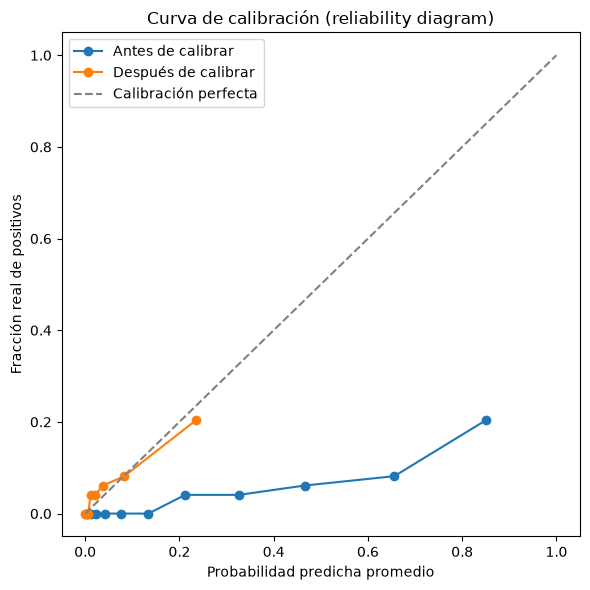

method='sigmoid' (Platt) recomendado por el tamaño de muestra;
probá 'isotonic' solo si X_calib tiene bastante más de 1000 filas.


In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred_before, frac_pos_before, marker="o", label="Antes de calibrar")
ax.plot(mean_pred_after, frac_pos_after, marker="o", label="Después de calibrar")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibración perfecta")
ax.set_xlabel("Probabilidad predicha promedio")
ax.set_ylabel("Fracción real de positivos")
ax.set_title("Curva de calibración (reliability diagram)")
ax.legend()
plt.tight_layout()
plt.show()

print("method='sigmoid' (Platt) recomendado por el tamaño de muestra;")
print("probá 'isotonic' solo si X_calib tiene bastante más de 1000 filas.")

### Guardar el modelo final

El modelo a usar en producción/inferencia es `calibrated_model` (ya envuelve a `best_model` y devuelve probabilidades corregidas), no `best_model` solo.

In [16]:
import joblib
from pathlib import Path

model_path = Path("../data/final_model.pkl").resolve()
joblib.dump(calibrated_model, model_path)
print(f"Modelo calibrado guardado en {model_path}")

Modelo calibrado guardado en C:\Users\marti\Documents\Posgrado\Aprendizaje de Maquina\tp_adm_ceia\data\final_model.pkl


## 7) Conclusiones